In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, spearmanr, pearsonr

# -------------------------------- set the seed + helper function ------------------------------------
SEED = 42
rng = np.random.default_rng(SEED)

def p_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

# -------------------------------- clean and rerank ------------------------------------
df = pd.read_csv("../data/ACAI_CSRankings_manually_matched.csv")

setting = "COLLAPSE_INTO_BOTTOM_RANK"
if setting == "NO_UNRANKED":

    # ensure csrankings_rank is numeric
    df['csrankings_rank'] = pd.to_numeric(df['csrankings_rank'], errors='coerce')

    # treat -1 as pd.NaN so they rank last
    df.loc[df['csrankings_rank'] < 0, 'csrankings_rank'] = pd.NA

    # normalized ranking: 1 = best csrankings rank
    df['csrankings_rank_normalized'] = (
        df['csrankings_rank']
        .rank(method='dense', ascending=True, na_option='keep')
    )

elif setting == "COLLAPSE_INTO_BOTTOM_RANK":

    # ensure csrankings_rank is numeric
    df['csrankings_rank'] = pd.to_numeric(df['csrankings_rank'], errors='coerce')

    # treat -1 as pd.NaN so they rank last
    df.loc[df['csrankings_rank'] < 0, 'csrankings_rank'] = pd.NA

    # normalized ranking: 1 = best csrankings rank
    df['csrankings_rank_normalized'] = (
        df['csrankings_rank']
        .rank(method='dense', ascending=True, na_option='bottom') # collapse all unranked into 1 bottom rank
    )

display(df)
df.to_csv("../data/ACAI_CSRankings_normalized.csv")

# -------------------------------- perform analysis ------------------------------------
df['rank_gap'] = df['Rank'] - df['csrankings_rank_normalized']
df.groupby('Type')['rank_gap'].describe().round(2)

group_cols = [
    'Research Activity',
    'Regional Coverage',
    'size_bucket',
    'Type'
]

MIN_N = 5
N_BOOT = 1000

results = []

# Analysis loop
for col in group_cols:
    for group, gdf in df.groupby(col):

        gdf = gdf[['Rank', 'csrankings_rank_normalized', 'rank_gap']].dropna()

        n = len(gdf)
        if n <= MIN_N:
            continue

        x = gdf['Rank'].values
        y = gdf['csrankings_rank_normalized'].values

        # min/max rank_gap for this group
        rank_gap_min = gdf['rank_gap'].min()
        rank_gap_max = gdf['rank_gap'].max()
        rank_gap_mean = gdf['rank_gap'].mean()
        rank_gap_std = gdf['rank_gap'].std()

        # skip groups with <2 unique values in either series
        if np.unique(x).size < 2 or np.unique(y).size < 2:
            continue

        # correlations
        pearson, pearson_p = pearsonr(x, y)
        spearman, spearman_p = spearmanr(x, y)
        kendall, kendall_p = kendalltau(x, y)
        pearson_sig = f"{pearson:.2f}{p_stars(pearson_p)}"
        spearman_sig = f"{spearman:.2f}{p_stars(spearman_p)}"
        kendall_sig = f"{kendall:.2f}{p_stars(kendall_p)}"

        # bootstrap CI for spearman
        def is_constant(arr):
            return np.unique(arr).size < 2

        boot = []
        constant_count = 0

        for b in range(N_BOOT):
            idx = rng.choice(n, n, replace=True)

            xb = x[idx]
            yb = y[idx]

            if is_constant(xb) or is_constant(yb):
                constant_count += 1
                print(
                    f"[CONST BOOT] {col} | {group} | iter={b} | "
                    f"x_unique={np.unique(xb).size} | y_unique={np.unique(yb).size}"
                )
                boot.append(np.nan)
                continue

            boot.append(
                pd.Series(xb).corr(pd.Series(yb), method='spearman')
            )

        boot = np.asarray(boot)


        # calculate CI, check NANs
        boot = np.asarray(boot)
        nan_rate = np.mean(np.isnan(boot))
        print(col, group, "NaN rate:", nan_rate, len(boot), len(boot[~np.isnan(boot)]))
        boot = boot[~np.isnan(boot)]
        ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

        results.append({
            'grouping': col,
            'group': group,
            'n': n,

            # raw correlations
            'pearson_corr': pearson,
            'pearson_p': pearson_p,
            'spearman_corr': spearman,
            'spearman_p': spearman_p,
            'kendall_tau': kendall,
            'kendall_p': kendall_p,

            # formatted (for tables)
            'pearson_corr_sig': pearson_sig,
            'spearman_corr_sig': spearman_sig,
            'kendall_tau_sig': kendall_sig,

            'spearman_ci_low': ci_low,
            'spearman_ci_high': ci_high,
            'rank_gap_min': rank_gap_min,
            'rank_gap_max': rank_gap_max,
            'rank_gap_mean': rank_gap_mean,
            'rank_gap_std': rank_gap_std
        })

        print(
            f"{group} :: "
            f"Spearman={spearman_sig} "
            f"(p={spearman_p:.3g})"
        )


# Final results table
results_df = pd.DataFrame(results).sort_values(
    ['grouping', 'spearman_corr'], ascending=[True, False]
)

display(results_df.round(2))


,Rank,Percentile_Rank,Institution,Index,Type,Research Activity,Regional Coverage,size_bucket,ACAI_indicators,csrankings_rank,csrankings_rank_normalized
0,1,1,University of New Hampshire,U27,Public Research-Oriented,R1,Northeast,medium,81.82,105.0,24.0
1,2,3,Portland State University,U16,Public Research-Oriented,R2,West,large,80.30,96.0,22.0
2,3,3,Stanford University,U42,Private Research-Oriented,R1,West,medium,80.30,8.0,4.0
3,4,5,University of Texas at Austin,U2,Public Research-Oriented,R1,South,large,77.27,14.0,6.0
4,5,6,University of Notre Dame,U49,Private Research-Oriented,R1,Midwest,medium,75.76,42.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...
74,75,95,Grinnell College,U72,Teaching-Oriented/Liberal Arts,-,Midwest,small,34.85,NaN,29.0
75,76,96,Jackson State University,U9,Public Research-Oriented,R2,South,small,31.82,NaN,29.0
76,77,97,Clark Atlanta University,U40,Private Research-Oriented,R2,South,small,28.79,NaN,29.0
77,78,99,Creighton University,U55,Private Research-Oriented,R2,Midwest,medium,27.27,NaN,29.0


Research Activity R1 NaN rate: 0.0 1000 1000
R1 :: Spearman=0.24 (p=0.173)
[CONST BOOT] Research Activity | R2 | iter=2 | x_unique=18 | y_unique=1
[CONST BOOT] Research Activity | R2 | iter=576 | x_unique=16 | y_unique=1
Research Activity R2 NaN rate: 0.002 1000 998
R2 :: Spearman=0.11 (p=0.568)
Regional Coverage Midwest NaN rate: 0.0 1000 1000
Midwest :: Spearman=0.54* (p=0.0145)
Regional Coverage Northeast NaN rate: 0.0 1000 1000
Northeast :: Spearman=0.40 (p=0.0839)
Regional Coverage South NaN rate: 0.0 1000 1000
South :: Spearman=0.70*** (p=0.000361)
Regional Coverage West NaN rate: 0.0 1000 1000
West :: Spearman=0.34 (p=0.165)
size_bucket large NaN rate: 0.0 1000 1000
large :: Spearman=0.25 (p=0.212)
size_bucket medium NaN rate: 0.0 1000 1000
medium :: Spearman=0.49* (p=0.0132)
[CONST BOOT] size_bucket | small | iter=696 | x_unique=17 | y_unique=1
[CONST BOOT] size_bucket | small | iter=918 | x_unique=15 | y_unique=1
size_bucket small NaN rate: 0.002 1000 998
small :: Spearman=-0.

,grouping,group,n,pearson_corr,pearson_p,spearman_corr,spearman_p,kendall_tau,kendall_p,pearson_corr_sig,spearman_corr_sig,kendall_tau_sig,spearman_ci_low,spearman_ci_high,rank_gap_min,rank_gap_max,rank_gap_mean,rank_gap_std
4,Regional Coverage,South,21,0.63,0.00,0.70,0.00,0.55,0.00,0.63**,0.70***,0.55**,0.32,0.87,-20.0,48.0,14.33,19.56
2,Regional Coverage,Midwest,20,0.49,0.03,0.54,0.01,0.42,0.01,0.49*,0.54*,0.42*,0.14,0.80,-8.0,53.0,22.45,19.20
3,Regional Coverage,Northeast,20,0.35,0.13,0.40,0.08,0.29,0.10,0.35,0.40,0.29,-0.04,0.73,-23.0,53.0,16.10,23.61
5,Regional Coverage,West,18,0.35,0.16,0.34,0.17,0.26,0.17,0.35,0.34,0.26,-0.18,0.70,-20.0,53.0,13.78,20.58
0,Research Activity,R1,33,0.24,0.19,0.24,0.17,0.16,0.19,0.24,0.24,0.16,-0.11,0.55,-23.0,53.0,10.52,19.75
1,Research Activity,R2,30,0.00,0.99,0.11,0.57,0.08,0.57,0.00,0.11,0.08,-0.27,0.47,-20.0,53.0,20.60,21.94
10,Type,Public Research-Oriented,33,0.44,0.01,0.47,0.01,0.32,0.01,0.44*,0.47**,0.32*,0.16,0.71,-23.0,53.0,12.18,19.80
9,Type,Private Research-Oriented,30,0.35,0.05,0.41,0.02,0.32,0.02,0.35,0.41*,0.32*,0.06,0.71,-20.0,53.0,18.77,22.59
7,size_bucket,medium,25,0.45,0.02,0.49,0.01,0.37,0.02,0.45*,0.49*,0.37*,0.09,0.78,-23.0,49.0,13.00,20.17
6,size_bucket,large,27,0.26,0.20,0.25,0.21,0.16,0.25,0.26,0.25,0.16,-0.18,0.61,-20.0,53.0,9.56,18.74


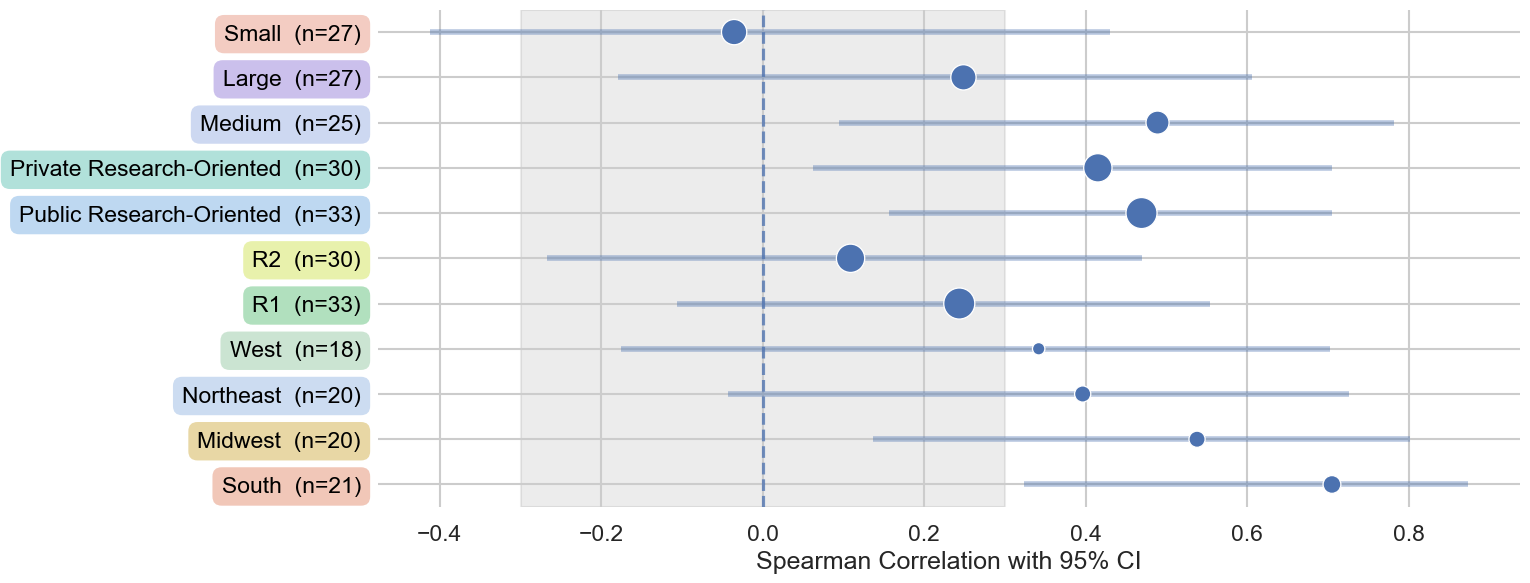

In [2]:
import matplotlib.colors as mcolors
import numpy as np

def darken_color(hex_color, factor=0.03):
    """
    Darken a hex color by multiplying RGB channels.
    factor < 1 → darker
    """
    rgb = np.array(mcolors.to_rgb(hex_color))
    return mcolors.to_hex(rgb * factor)

def text_color_for_bg(hex_color):
    """
    Choose black/white text based on luminance.
    """
    r, g, b = mcolors.to_rgb(hex_color)
    luminance = 0.299*r + 0.587*g + 0.114*b
    return "black" if luminance > 0.6 else "white"


COLOR_MAP = {
    "Type": {
        "Public Research-Oriented": "#B7D4F0",
        "Private Research-Oriented": "#A9DED6",
        "Teaching-Oriented/Liberal Arts": "#E0CEF2"
    },
    "Research Activity": {
        "R1": "#A9DDB7",
        "R2": "#E6F0A3",
        "-": "#E2E2E2"
    },
    "Regional Coverage": {
        "South": "#F0C1B1",
        "Midwest": "#E6D39B",
        "Northeast": "#C7D9F0",
        "West": "#C6E2CE"
    },
    "size_bucket": {
        "small": "#F2C7BC",
        "medium": "#C8D4F0",
        "large": "#C6B9EA"
    }
}

LABEL_MAP = {
    "Type": {
        "Teaching-Oriented/Liberal Arts": "Teaching-Oriented/Liberal Arts",
        "Private Research-Oriented": "Private Research-Oriented",
        "Public Research-Oriented": "Public Research-Oriented",
    },
    "Regional Coverage": {
        "Midwest": "Midwest",
        "South": "South",
        "Northeast": "Northeast",
        "West": "West",
    },
    "Research Activity": {
        "R1": "R1",
        "R2": "R2",
        "-": "None",
    },
    "size_bucket": {
        "small": "Small",
        "medium": "Medium",
        "large": "Large",
    }
}

SUBGROUP_DISPLAY_NAMES = {
    "Type": "Institution Type",
    "Regional Coverage": "Region",
    "Research Activity": "Research Activity",
    "size_bucket": "Institution Size",
}

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

# Prepare plot dataframe
plot_df = (
    results_df
    # .sort_values("spearman_corr")
    .reset_index(drop=True)
)

# Build pretty labels using LABEL_MAP + SUBGROUP_DISPLAY_NAMES
def make_label(row):
    subgroup = row["grouping"]
    level = row["group"]

    pretty_level = LABEL_MAP.get(subgroup, {}).get(level, level)
    pretty_group = SUBGROUP_DISPLAY_NAMES.get(subgroup, subgroup)

    return f"{pretty_level}  (n={row['n']})" # {pretty_group}: 

plot_df["pretty_label"] = plot_df.apply(make_label, axis=1)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(23,6.5))

# CI bars
ax.hlines(
    y=plot_df.index,
    xmin=plot_df["spearman_ci_low"],
    xmax=plot_df["spearman_ci_high"],
    linewidth=4,
    alpha=0.4
)

# Points
sns.scatterplot(
    data=plot_df,
    x="spearman_corr",
    y=plot_df.index,
    size="n",
    sizes=(80, 500),
    legend=False,
    ax=ax,
    zorder=3
)

# Zero reference line
ax.axvline(0, linestyle="--", alpha=0.5)

# ---- Y-axis labels with colored boxes ----
ax.set_yticks(plot_df.index)
ax.set_yticklabels(plot_df["pretty_label"])

for tick, (_, row) in zip(ax.get_yticklabels(), plot_df.iterrows()):
    subgroup = row["grouping"]
    level = row["group"]

    bg = COLOR_MAP.get(subgroup, {}).get(level, "#FFFFFF")

    tick.set_bbox(dict(
        facecolor=bg,
        edgecolor="none",
        boxstyle="round,pad=0.4",
        alpha=0.9
    ))
    tick.set_color(text_color_for_bg(bg))
    tick.set_multialignment("center")

# ---- Labels & title ----
ax.set_xlabel("Spearman Correlation with 95% CI")
ax.set_ylabel("")
# ax.set_title(
#     "Relationship Between ACAI Rank and CSRankings$_{AI}$ Rank\n"
#     "Spearman Correlation with 95% CI"
# )

sns.despine(left=True, bottom=True)
plt.tight_layout(rect=(0.32, 0.05, 1, 1))

# Zero reference line
ax.axvline(0, linestyle="--", alpha=0.5)

# Grey band between -0.3 and 0.3
ax.axvspan(-0.30, 0.30, color="grey", alpha=0.15, zorder=0)


plt.show()
